
# CAP4453 Assignment 2 — **Two‑Layer CNN (Minimal Template)**

This JupyterNotebook is from \
**Name:** Xavier Andres Soto Baron. **UCF ID:** 5601517



## 1. Setup (imports, device, seeds)

In [1]:
# Minimal imports
import os, random, time
from typing import Tuple

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

# Reproducibility (optional)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# Device (CPU/GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda



## 2. Datasets & Transforms (augmentation + image normalisation)

In [2]:
# Choose dataset and preprocessing settings
dataset_name = 'cifar10'
AUGMENT = True
USE_NORMALIZE = True

# Batch Size and Validation settings chosen
batch_size = 128
val_ratio = 0.1

#Using CIFAR10
if dataset_name.lower() == 'cifar10':

    # Training transformations
    train_tfms_list = []

    if AUGMENT:
        train_tfms_list += [transforms.RandomCrop(32, padding=4),transforms.RandomHorizontalFlip(p=0.5)]

    train_tfms_list += [transforms.ToTensor()]

    if USE_NORMALIZE:
        train_tfms_list += [transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),std=(0.2470, 0.2435, 0.2616))]

    # Validation/test transforms, NO Augmentation
    test_tfms_list = [transforms.ToTensor()]

    if USE_NORMALIZE:
        test_tfms_list += [transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),std=(0.2470, 0.2435, 0.2616))]

    train_tfms = transforms.Compose(train_tfms_list)
    test_tfms = transforms.Compose(test_tfms_list)

    # We create two copies of the CIFAR-10 training data:
    # one with augmentation for training,
    # one without augmentation for validation.
    full_train_aug = datasets.CIFAR10(root='./data',train=True,download=True,transform=train_tfms)

    full_train_eval = datasets.CIFAR10(root='./data',train=True,download=True,transform=test_tfms)

    test_dataset = datasets.CIFAR10(root='./data',train=False,download=True,transform=test_tfms)

    num_classes = 10
    in_channels = 3

elif dataset_name.lower() == 'mnist':

    train_tfms_list = []

    if AUGMENT:
        train_tfms_list += [transforms.RandomRotation(10)]

    train_tfms_list += [transforms.ToTensor()]

    if USE_NORMALIZE:
        train_tfms_list += [transforms.Normalize(mean=(0.1307,),std=(0.3081,))]

    test_tfms_list = [transforms.ToTensor()]

    if USE_NORMALIZE:
        test_tfms_list += [transforms.Normalize(mean=(0.1307,),std=(0.3081,))]

    train_tfms = transforms.Compose(train_tfms_list)
    test_tfms = transforms.Compose(test_tfms_list)

    full_train_aug = datasets.MNIST(root='./data',train=True,download=True,transform=train_tfms)

    full_train_eval = datasets.MNIST(root='./data',train=True,download=True,transform=test_tfms)

    test_dataset = datasets.MNIST(root='./data',train=False,download=True,transform=test_tfms)

    num_classes = 10
    in_channels = 1

else:
    raise ValueError('Unknown dataset: choose cifar10 or mnist')

# Reproducible train/validation split
dataset_size = len(full_train_aug)
val_size = int(val_ratio * dataset_size)
train_size = dataset_size - val_size

generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(dataset_size, generator=generator).tolist()

val_indices = indices[:val_size]
train_indices = indices[val_size:]

# Training gets augmentation
train_ds = torch.utils.data.Subset(full_train_aug,train_indices)

# Validation uses the same images but NO augmentation
val_ds = torch.utils.data.Subset(full_train_eval,val_indices)

pin_memory = (device.type == 'cuda')

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=pin_memory
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=pin_memory
)

print(f'Train: {len(train_ds)} | 'f'Val: {len(val_ds)} | 'f'Test: {len(test_dataset)}')


100%|██████████| 170M/170M [04:31<00:00, 629kB/s]


Train: 45000 | Val: 5000 | Test: 10000



## 3. Two‑Layer CNN (only) — add BatchNorm where marked

In [3]:
class TwoLayerCNN(nn.Module):
    """
    Two convolutional blocks:

    Conv -> BatchNorm -> ReLU -> MaxPool
    Conv -> BatchNorm -> ReLU -> MaxPool
    Flatten -> Linear
    """

    def __init__(self,in_channels,num_classes,hidden_channels1=32,hidden_channels2=64,use_bn=False):
        super().__init__()

        self.use_bn = use_bn

        # Convolution block 1
        self.conv1 = nn.Conv2d(
            in_channels,
            hidden_channels1,
            kernel_size=3,
            padding=1,
            bias=not use_bn
        )

        self.bn1 = (
            nn.BatchNorm2d(hidden_channels1)
            if use_bn
            else nn.Identity()
        )

        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        # Convolution block 2
        self.conv2 = nn.Conv2d(
            hidden_channels1,
            hidden_channels2,
            kernel_size=3,
            padding=1,
            bias=not use_bn
        )

        self.bn2 = (
            nn.BatchNorm2d(hidden_channels2)
            if use_bn
            else nn.Identity()
        )

        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        # LazyLinear determines the flattened size
        # automatically on the first forward pass.
        self.classifier = nn.LazyLinear(num_classes)

    def forward(self, x):

        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        # Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        # Flatten: [B, C, H, W] -> [B, C*H*W]
        x = torch.flatten(x, start_dim=1)

        # Classification logits
        x = self.classifier(x)

        return x

## 4. Optimizer & (optional) LR scheduler

In [4]:
#Hyperparameters
learning_rate = 1e-3
weight_decay = 1e-4

model = TwoLayerCNN(
    in_channels=in_channels,
    num_classes=num_classes,
    hidden_channels1=32,
    hidden_channels2=64,
    use_bn=True
).to(device)

optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate,weight_decay=weight_decay)

# Reduce the learning rate during later training
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=15,
    gamma=0.2
)

criterion = nn.CrossEntropyLoss()

print(model)


TwoLayerCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU(inplace=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU(inplace=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (classifier): LazyLinear(in_features=0, out_features=10, bias=True)
)


## 5. Training / Validation

In [5]:
#Training
def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clear gradients from previous batch
        optimizer.zero_grad()

        # Forward pass
        logits = model(images)

        # Compute classification loss
        loss = criterion(logits, labels)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()


        #Acumulate Statistics
        batch_size_current = images.size(0)

        running_loss += loss.item() * batch_size_current

        predictions = logits.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += batch_size_current

    avg_loss = running_loss / total
    avg_accuracy = 100.0 * correct / total

    return avg_loss, avg_accuracy

#Evaluation of the Model
@torch.no_grad()
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Forward only -- no backpropagation
        logits = model(images)

        loss = criterion(logits, labels)

        batch_size_current = images.size(0)

        running_loss += loss.item() * batch_size_current

        predictions = logits.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += batch_size_current

    avg_loss = running_loss / total
    avg_accuracy = 100.0 * correct / total

    return avg_loss, avg_accuracy


## 6. Run training (log metrics, make plots)

Epoch 01/30 | Train Loss: 1.5641 | Train Acc: 43.95% | Val Loss: 1.2385 | Val Acc: 56.50%
Epoch 02/30 | Train Loss: 1.2414 | Train Acc: 55.84% | Val Loss: 1.0302 | Val Acc: 63.48%
Epoch 03/30 | Train Loss: 1.1355 | Train Acc: 60.01% | Val Loss: 1.0175 | Val Acc: 64.76%
Epoch 04/30 | Train Loss: 1.0723 | Train Acc: 62.51% | Val Loss: 0.9239 | Val Acc: 68.26%
Epoch 05/30 | Train Loss: 1.0330 | Train Acc: 63.86% | Val Loss: 0.9178 | Val Acc: 68.40%
Epoch 06/30 | Train Loss: 0.9944 | Train Acc: 65.22% | Val Loss: 0.8668 | Val Acc: 70.10%
Epoch 07/30 | Train Loss: 0.9705 | Train Acc: 66.16% | Val Loss: 0.8586 | Val Acc: 71.10%
Epoch 08/30 | Train Loss: 0.9412 | Train Acc: 67.06% | Val Loss: 0.8631 | Val Acc: 71.42%
Epoch 09/30 | Train Loss: 0.9223 | Train Acc: 67.77% | Val Loss: 0.8312 | Val Acc: 71.46%
Epoch 10/30 | Train Loss: 0.9036 | Train Acc: 68.76% | Val Loss: 0.8875 | Val Acc: 69.92%
Epoch 11/30 | Train Loss: 0.8859 | Train Acc: 69.14% | Val Loss: 0.8128 | Val Acc: 72.48%
Epoch 12/3

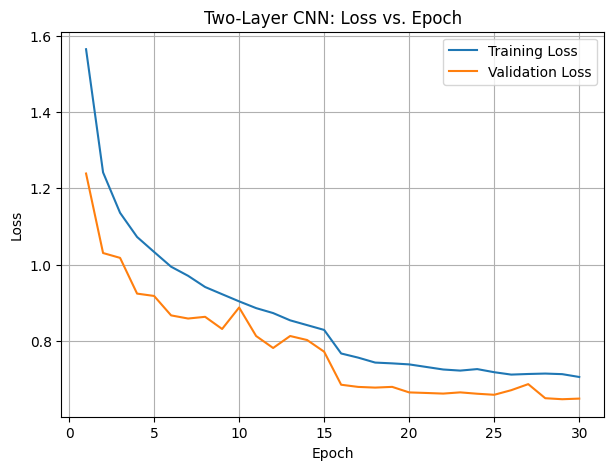

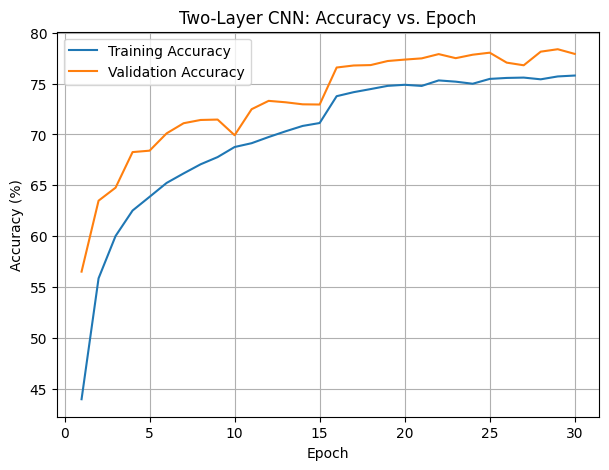

In [6]:
num_epochs = 30

train_hist = []
val_hist = []

for epoch in range(1, num_epochs + 1):

    train_loss, train_acc = train_one_epoch(model,train_loader,optimizer,criterion,device)

    val_loss, val_acc = evaluate(model,val_loader,criterion,device)

    train_hist.append((train_loss, train_acc))

    val_hist.append((val_loss, val_acc))

    if scheduler is not None:
        scheduler.step()

    print(f'Epoch {epoch:02d}/{num_epochs} | 'f'Train Loss: {train_loss:.4f} | 'f'Train Acc: {train_acc:.2f}% | 'f'Val Loss: {val_loss:.4f} | 'f'Val Acc: {val_acc:.2f}%')


#Create Plots --> Loss and Accuracy curves with Matplotlib:

epochs = range(1, num_epochs + 1)

train_losses = [x[0] for x in train_hist]
train_accs = [x[1] for x in train_hist]

val_losses = [x[0] for x in val_hist]
val_accs = [x[1] for x in val_hist]



#Plotting Loss
plt.figure(figsize=(7, 5))

plt.plot(epochs,train_losses,label='Training Loss')

plt.plot(epochs,val_losses,label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Two-Layer CNN: Loss vs. Epoch')
plt.legend()
plt.grid()

plt.show()


#Accuracy
plt.figure(figsize=(7, 5))

plt.plot(epochs,train_accs,label='Training Accuracy')

plt.plot(epochs,val_accs,label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Two-Layer CNN: Accuracy vs. Epoch')
plt.legend()
plt.grid()

plt.show()


In [8]:
#Test Loss and Test Accuracy
# Final evaluation on the test dataset

test_loss, test_acc = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.2f}%')

Test Loss: 0.6635
Test Accuracy: 77.51%


## 7. Analysis — misclassified examples (optional)

In [7]:
#Setting Classes from CIFAR10
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

model.eval()

#Storing misclassified classes
misclassified = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        predictions = logits.argmax(dim=1)

        wrong = predictions != labels

        for image, true_label, pred_label in zip(
            images[wrong],
            labels[wrong],
            predictions[wrong]
        ):

            misclassified.append((image.cpu(),true_label.item(),pred_label.item()))

            if len(misclassified) >= 8:
                break

        if len(misclassified) >= 8:
            break

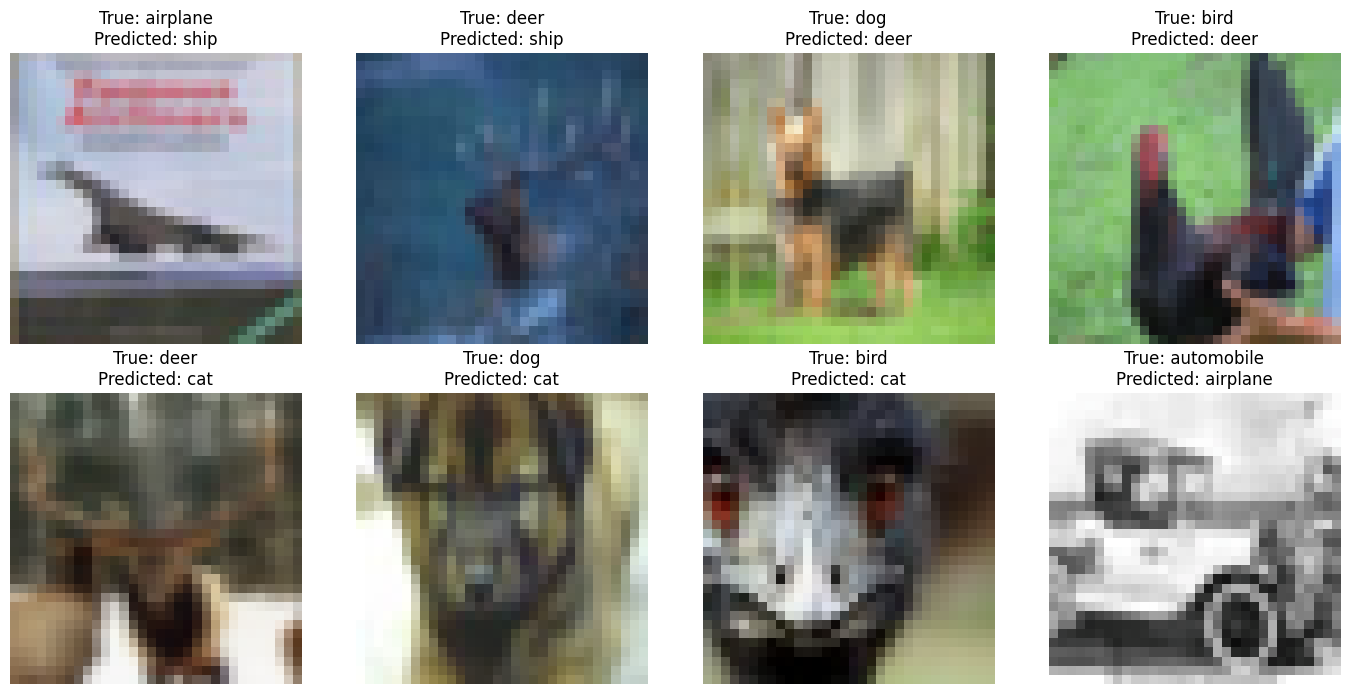

In [10]:
# CIFAR-10 mean/std used for normalization
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

plt.figure(figsize=(14, 7))

for i, (image, true_label, pred_label) in enumerate(misclassified):

    # Undo normalization so image displays correctly
    image = image * std + mean
    image = image.clamp(0, 1)

    # Convert from C x H x W to H x W x C
    image = image.permute(1, 2, 0)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)

    plt.title(
        f"True: {class_names[true_label]}\n"
        f"Predicted: {class_names[pred_label]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()